# Fitting Bond ASW and Z-Spread Curves

Fitting a bond curve to asset swap spreads and z-scores, using the range of parametric functions provided

In [1]:
import os
import datetime as dt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from financepy.utils import Date, from_datetime
from financepy.utils.calendar import Calendar, CalendarTypes
from financepy.utils.frequency import FrequencyTypes
from financepy.utils.day_count import DayCountTypes
from financepy.market.curves.bond_parametric_yield_curve import BondParametricYieldCurve
from financepy.market.curves.curve_fits import *
from financepy.market.curves.interpolator import InterpTypes
from financepy.products.bonds.bond import Bond
from financepy.products.bonds.bond_market import get_bond_market_conventions
from financepy.products.rates.ibor_single_curve import IborSingleCurve
from financepy.products.rates.ibor_benchmarks_report import dataframe_to_benchmarks

### Load up some Bond and Curve Data

In [3]:

bond_dataframe = pd.read_csv("./data/giltbondprices.txt", sep='\t')
bond_dataframe['mid'] = 0.5*(bond_dataframe['bid'] + bond_dataframe['ask'])
bond_dataframe['maturity'] = pd.to_datetime(bond_dataframe['maturity'], format="%d-%b-%y")

In [4]:
bond_dataframe.head()
len(bond_dataframe)

33

In [5]:
dfbm = pd.read_csv('./data/GBP_OIS_20120919.csv', index_col=0)
dfbm['base_date'] = pd.to_datetime(dfbm['base_date'], dayfirst=True)
dfbm['base_date'] = pd.to_datetime(dfbm['base_date'], dayfirst=True)
dfbm['base_date'] = pd.to_datetime(dfbm['base_date'], dayfirst=True)
dfbm['base_date'] = pd.to_datetime(dfbm['base_date'], dayfirst=True)
dfbm['start_dt'] = pd.to_datetime(dfbm['start_dt'], dayfirst=True)  # allow tenors
dfbm['maturity_dt'] = pd.to_datetime(dfbm['maturity_dt'], dayfirst=True)  # allow tenors

In [6]:
valuation_date = from_datetime(dfbm.loc[0, 'base_date'])
cal = CalendarTypes.LONDON
bms = dataframe_to_benchmarks(dfbm, asof_date=valuation_date, calendar_type=cal)
depos = bms['IborDeposit']
fras = bms['IborFRA']
swaps = bms['IborSwap']

fras.sort(key=lambda fra: fra.maturity_dt)
ois_curve = IborSingleCurve(valuation_date, depos, fras, swaps, InterpTypes.LINEAR_ZERO_RATES)

In [7]:
# SPECIFY UK BOND CONVENTIONS
freq_type = FrequencyTypes.SEMI_ANNUAL
accrual_type = DayCountTypes.ACT_ACT_ICMA
settlement = valuation_date

In [8]:
bonds = []
asws = []
z_spreads = []

# LOAD BONDS AND CREATE A VECTOR OF FINBOND AND THEIR CORRESPONDING asms/z-spreads

for index, bondData in bond_dataframe.iterrows():

    date_string = bondData['maturity']
    matDatetime = bondData['maturity']
    maturity_dt = from_datetime(matDatetime)
    coupon = bondData['coupon']/100.0
    clean_price = bondData['mid']
    issue_date = Date(maturity_dt.d, maturity_dt.m, 2000)
    bond = Bond(issue_date, maturity_dt, coupon, freq_type, accrual_type)

    z_spread = bond.z_spread(settlement, clean_price, ois_curve)
    asset_swap_spread = bond.asset_swap_spread(ois_curve.value_dt, clean_price, ois_curve)

    bonds.append(bond)
    asws.append(asset_swap_spread)
    z_spreads.append(z_spread)

### Eyeball asset swap spreads and z-spreads

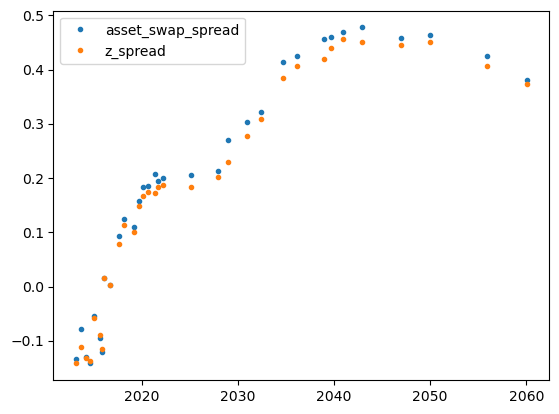

In [9]:
plt.plot(bond_dataframe['maturity'], np.array(asws)*100, '.', label='asset_swap_spread')
plt.plot(bond_dataframe['maturity'], np.array(z_spreads)*100, '.', label='z_spread')
plt.legend(loc='best')
plt.show()


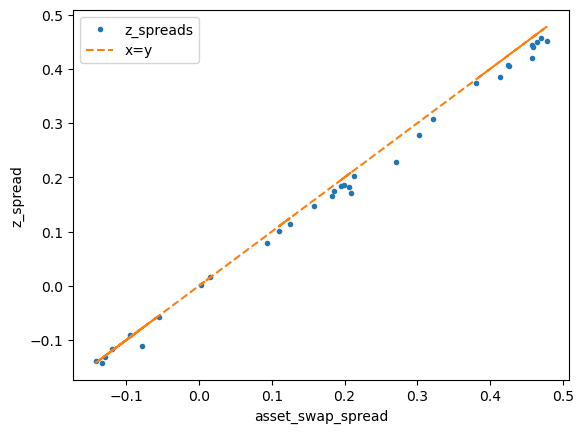

In [10]:
plt.plot(np.array(asws)*100, np.array(z_spreads)*100, '.', label='z_spreads')
plt.plot(np.array(asws)*100, np.array(asws)*100, '--', label = 'x=y')
plt.xlabel('asset_swap_spread')
plt.ylabel('z_spread')
plt.legend(loc='best')
plt.show()


## Fitting the Bond Curves

### Cubic Polynomial

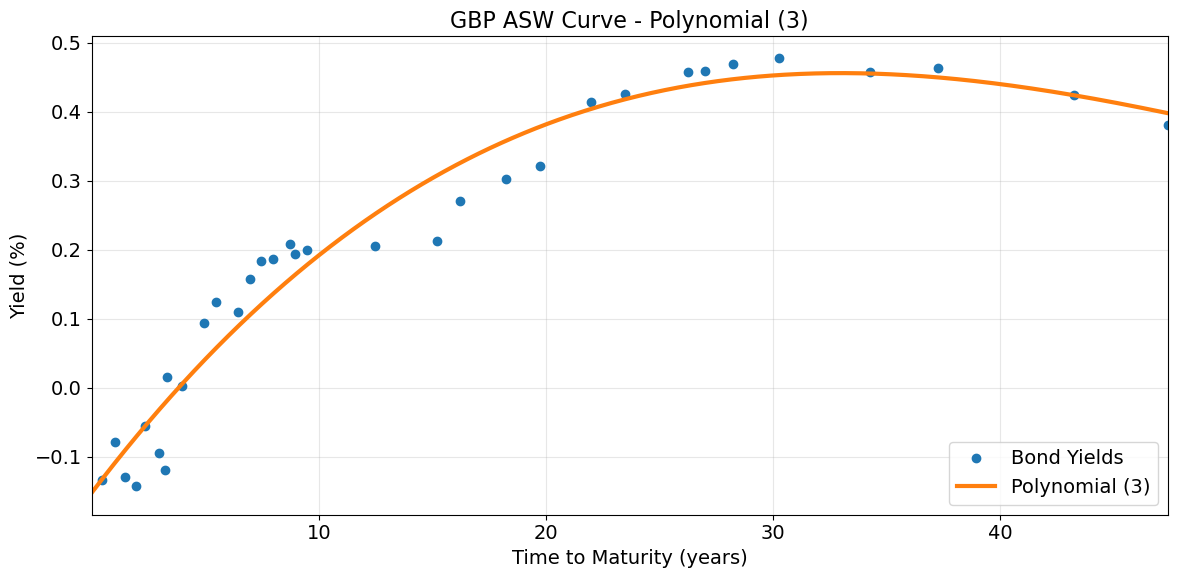

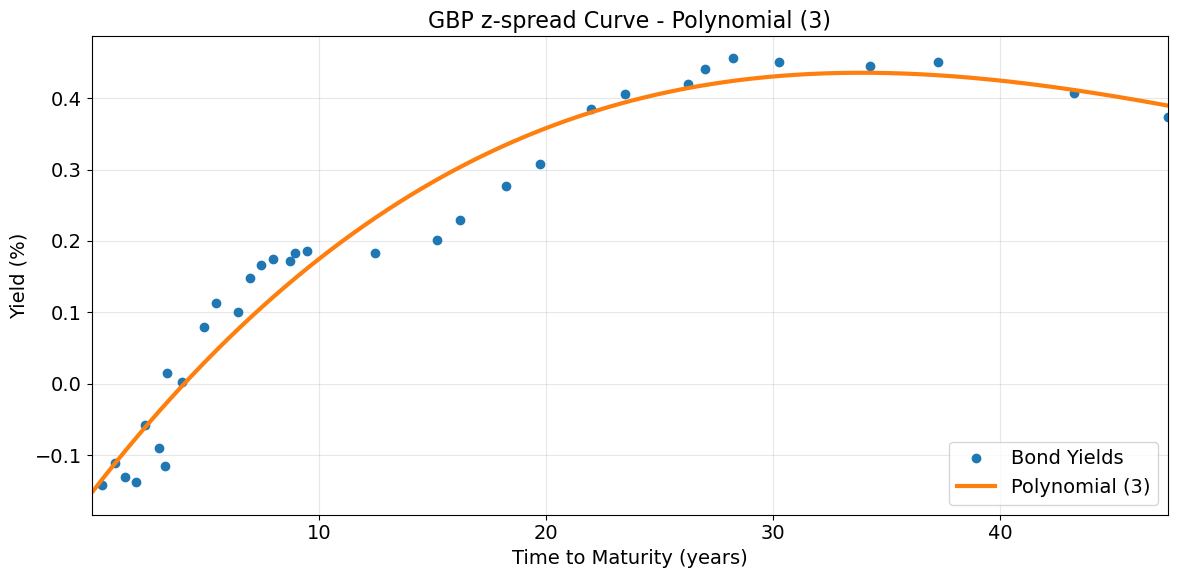

In [11]:
# FIT THE ASWS AND Z-SPREADS TO A CUBIC POLYNOMIAL
curve_fit_method = CurveFitPolynomial()
fittedCurve1a = BondParametricYieldCurve(settlement, bonds, asws, curve_fit_method)
fittedCurve1a.plot("GBP ASW Curve")
fittedCurve1z = BondParametricYieldCurve(settlement, bonds, z_spreads, curve_fit_method)
fittedCurve1z.plot("GBP z-spread Curve")

See the cubic coefficients

In [12]:
print(fittedCurve1a.curve_fit)

OBJECT TYPE: CurveFitPolynomial
Power: 3
t_scale: 47.37260273972603
Coefficient: -0.0015281491170782598
Coefficient: 0.01944098587368986
Coefficient: -0.019854929105141052
Coefficient: 0.005837394022546778



### Quintic Polynomial

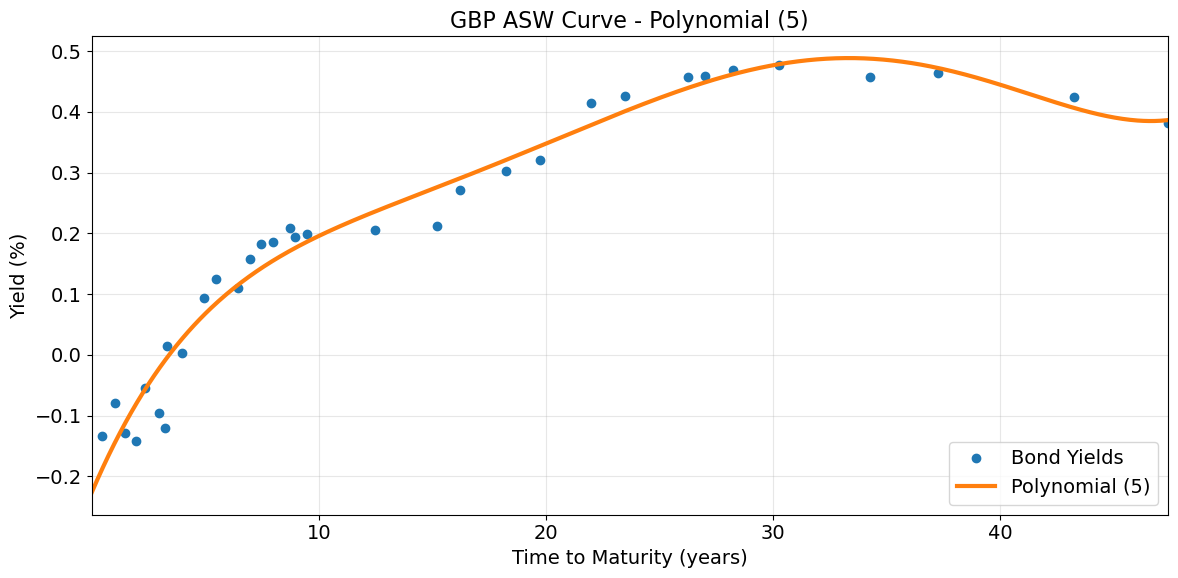

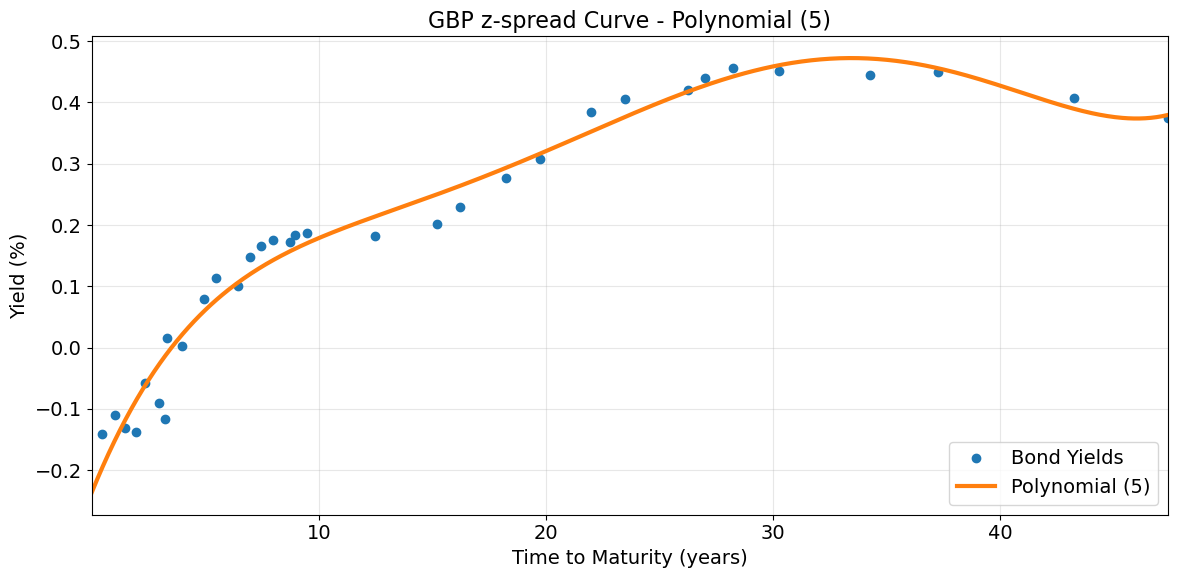

In [13]:
# FIT THE BOND ASWs and Z-SPREADs TO A QUINTIC POLYNOMIAL
curve_fit_method = CurveFitPolynomial(5)
fittedCurve2a = BondParametricYieldCurve(settlement, bonds, asws, curve_fit_method)
fittedCurve2a.plot("GBP ASW Curve")
fittedCurve2z = BondParametricYieldCurve(settlement, bonds, z_spreads, curve_fit_method)
fittedCurve2z.plot("GBP z-spread Curve")

See the quintic coefficients

In [14]:
print(fittedCurve2z.curve_fit)

OBJECT TYPE: CurveFitPolynomial
Power: 5
t_scale: 47.37260273972603
Coefficient: -0.002371483331097247
Coefficient: 0.043315679983909734
Coefficient: -0.18186667568571546
Coefficient: 0.4156080242895533
Coefficient: -0.4322834820786521
Coefficient: 0.16139388881534575



### Nelson-Siegel Curve

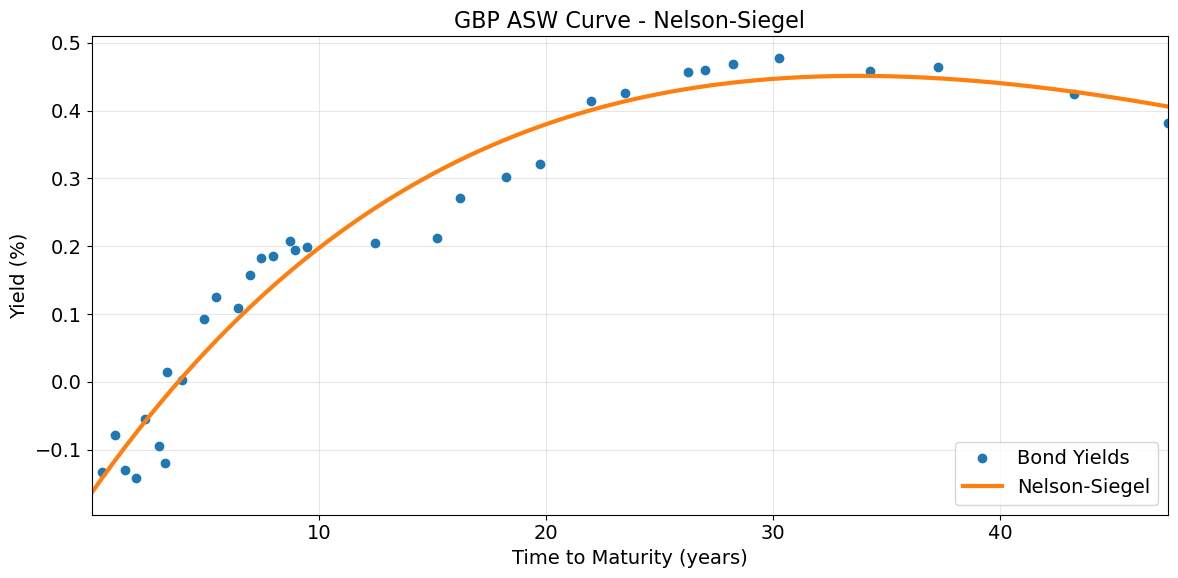

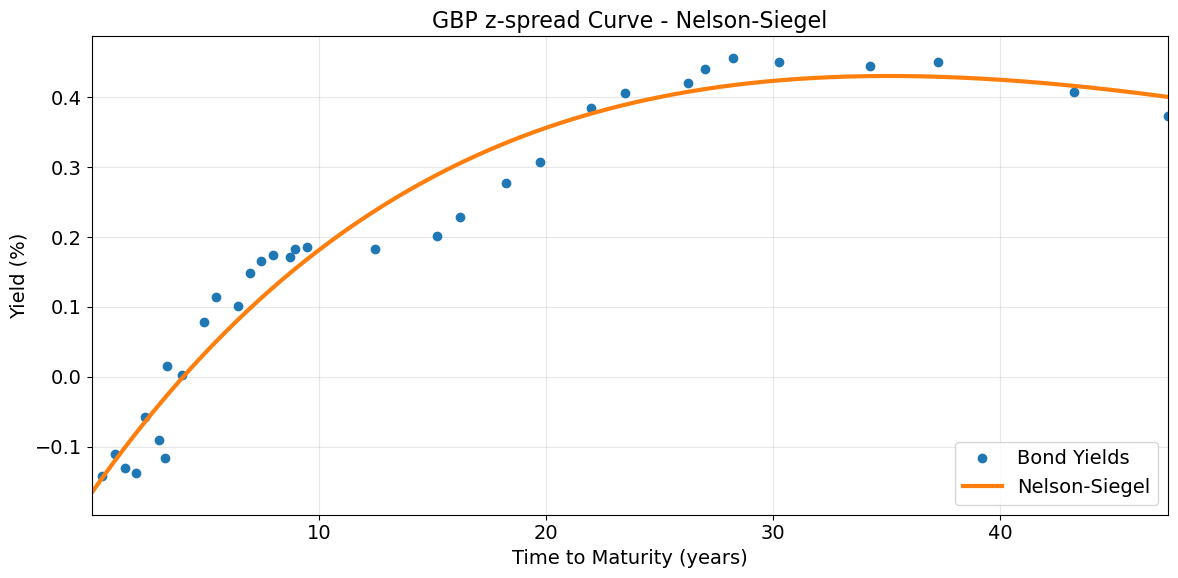

In [15]:
# FIT THE BONDS TO A NELSON-SIEGEL CURVE
curve_fit_method = CurveFitNelsonSiegel()
fittedCurve3a = BondParametricYieldCurve(settlement, bonds, asws, curve_fit_method)
fittedCurve3a.plot("GBP ASW Curve")
fittedCurve3z = BondParametricYieldCurve(settlement, bonds, z_spreads, curve_fit_method)
fittedCurve3z.plot("GBP z-spread Curve")

In [16]:
print(fittedCurve3a.curve_fit)

OBJECT TYPE: CurveFitNelsonSiegel
beta_1: -0.008662386706790775
beta_2: 0.007001692974481131
beta_3: 0.031519987654082295
tau: 26.500780589573374



### Nelson-Siegel Svensson Curve

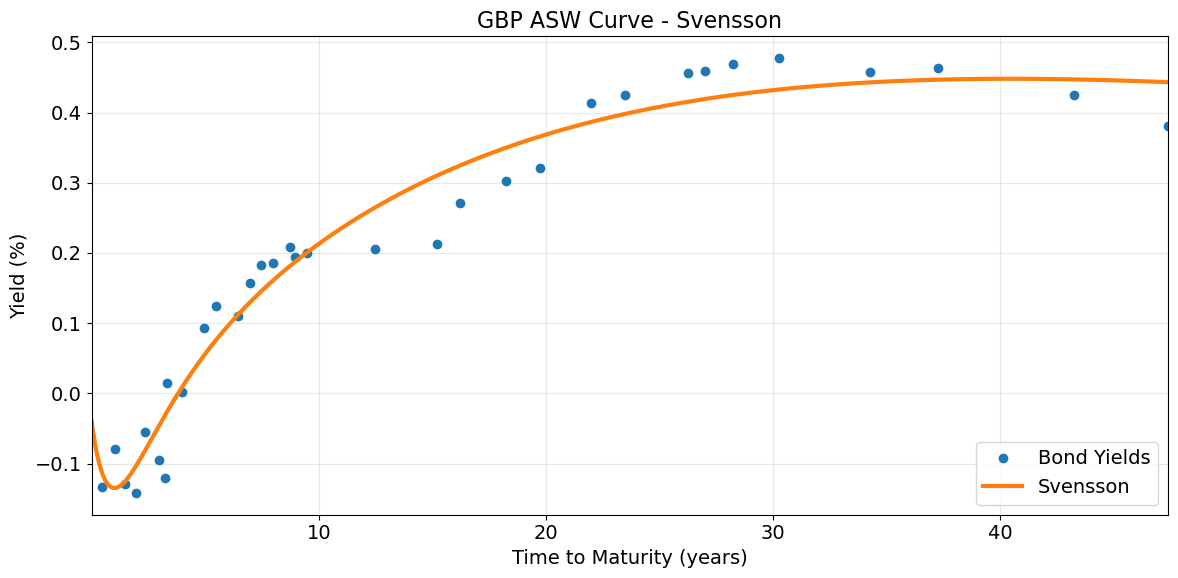

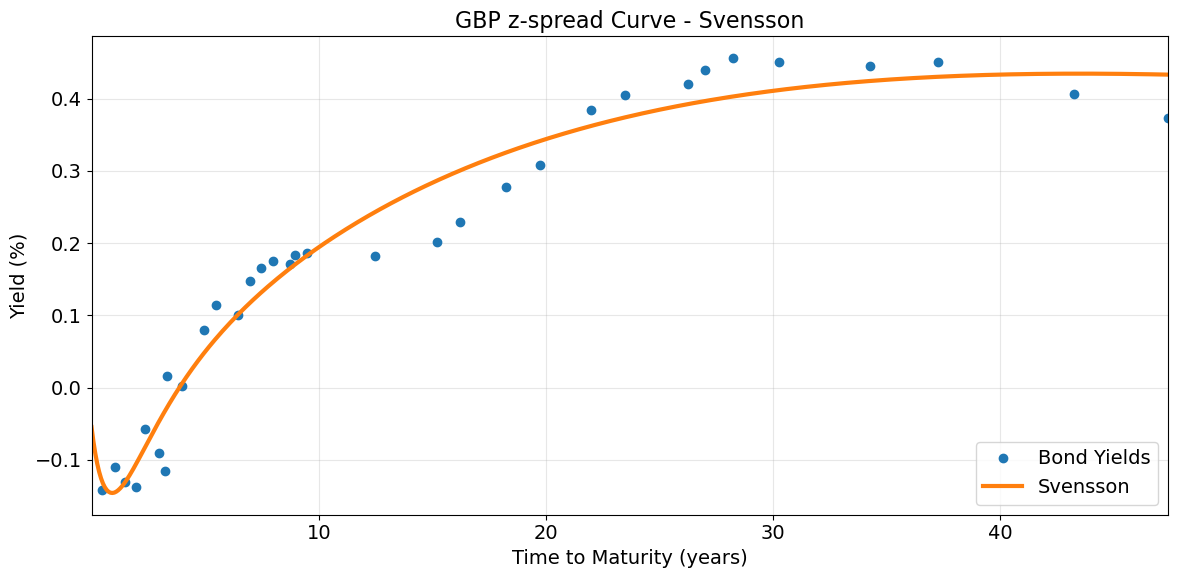

In [17]:
# FIT THE BONDS TO A NELSON-SIEGEL-SVENSSON CURVE
curve_fit_method = CurveFitSvensson()
fittedCurve4a = BondParametricYieldCurve(settlement, bonds, asws, curve_fit_method)
fittedCurve4a.plot("GBP ASW Curve")
fittedCurve4z = BondParametricYieldCurve(settlement, bonds, z_spreads, curve_fit_method)
fittedCurve4z.plot("GBP z-spread Curve")

In [18]:
print(fittedCurve4a.curve_fit)

OBJECT TYPE: CurveFitSvensson
beta_1: -5.4575056129873344e-05
beta_2: -0.0004934711821808538
beta_3: -0.004998963783836056
beta_4: 0.01507390931519073
tau_1: 0.7695222376999329
tau_2: 23.608185407418016



### B-Spline Curve

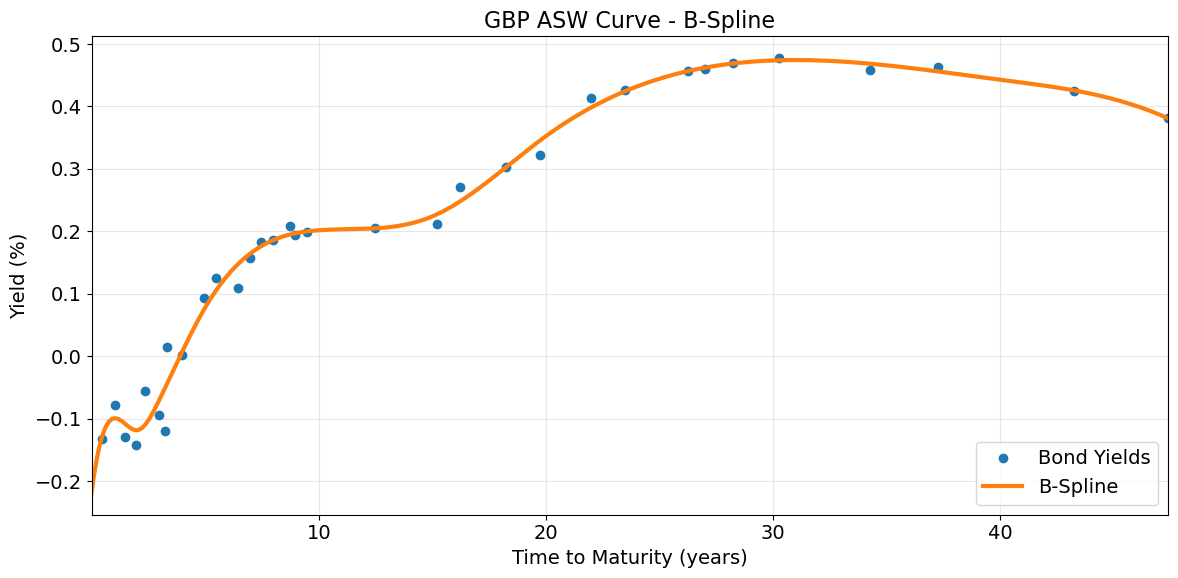

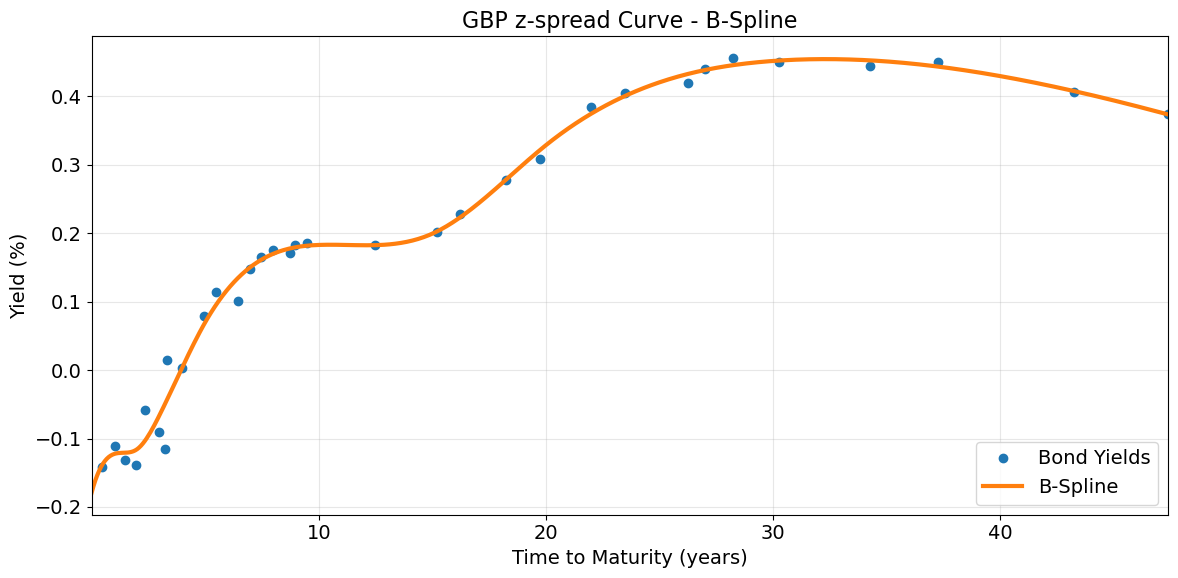

In [19]:
# FIT THE BONDS TO A B-SPLINE CURVE
curve_fit_method = CurveFitBSpline(power = 3, knot_years = [2, 3,5,10,15,20,30,40])
fittedCurve5a = BondParametricYieldCurve(settlement, bonds, asws, curve_fit_method)
fittedCurve5a.plot("GBP ASW Curve")
fittedCurve5z = BondParametricYieldCurve(settlement, bonds, z_spreads, curve_fit_method)
fittedCurve5z.plot("GBP z-spread Curve")

In [20]:
print(fittedCurve5a.curve_fit)

OBJECT TYPE: CurveFitBSpline
Power: 3
t_min: 0.0
t_max: 50.0
Knots: [0.04 0.06 0.1  0.2  0.3  0.4  0.6  0.8 ]
Coefficient 0: -0.0017954604370019945
Coefficient 1: -0.000968829773681655
Coefficient 2: -0.001486058376039546
Coefficient 3: -0.00046688885108903144
Coefficient 4: 0.0016072434900549814
Coefficient 5: 0.0019539738699945993
Coefficient 6: 0.0016426959439393514
Coefficient 7: 0.0040459377282624385
Coefficient 8: 0.004702837299218769
Coefficient 9: 0.004389569885325863
Coefficient 10: 0.0038103829660349284
Coefficient 11: 0.003495188764170638



## Accessing the Curve

You can access a yield from a date as follows

In [21]:
# EXTRACT A YIELD FROM A FITTED YIELD CURVE
maturity_dt = Date(19, 9, 2030)
interpolated_yield = fittedCurve5a.interp_yield(maturity_dt)
print(maturity_dt, interpolated_yield*100)

19-SEP-2030 0.2716112164600403


## Vectorisations

You can also access the curve using a time and this can be vectorised.

In [22]:
times = np.linspace(0,10,100)

In [23]:
interpolated_yields = fittedCurve5z.interp_yield(times)

In [24]:
interpolated_yields*100

array([-0.17954604, -0.16789621, -0.1579099 , -0.1494578 , -0.14241058,
       -0.13663891, -0.13201348, -0.12840495, -0.125684  , -0.12372132,
       -0.12238757, -0.12155343, -0.12108958, -0.12086669, -0.12075544,
       -0.12062651, -0.12035056, -0.11979828, -0.11884035, -0.11734743,
       -0.11519046, -0.11229564, -0.1087124 , -0.10450687, -0.09974518,
       -0.09449346, -0.08881782, -0.0827844 , -0.07645933, -0.06990872,
       -0.06319849, -0.05637703, -0.04946311, -0.04247262, -0.03542144,
       -0.02832547, -0.02120059, -0.01406268, -0.00692765,  0.00018863,
        0.00727026,  0.01430136,  0.02126604,  0.02814842,  0.03493259,
        0.04160268,  0.04814279,  0.05453704,  0.06076954,  0.0668244 ,
        0.07268614,  0.07834854,  0.08381465,  0.08908792,  0.09417183,
        0.09906981,  0.10378534,  0.10832185,  0.11268282,  0.11687169,
        0.12089193,  0.12474698,  0.1284403 ,  0.13197536,  0.13535561,
        0.13858449,  0.14166548,  0.14460202,  0.14739757,  0.15